#### Notebook Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/DAT255/voice-command-assistant")
os.environ["HF_HOME"] = str(PROJECT_ROOT/"data/cache/hf_home")
os.environ["HF_DATASETS_CACHE"] = str(PROJECT_ROOT/"data/cache/hf_datasets")
os.environ["TRANSFORMERS_CACHE"] = str(PROJECT_ROOT/"data/cache/transformers")

print("PROJECT_ROOT:", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/DAT255/voice-command-assistant


# 06 — Model improvements / experiments

Goal:
Improve the realistic 5-class model (up/down/left/right/unknown) while keeping the model small and fast.

Experiment 1 (E1): Downsample "unknown" in TRAIN only
- Keep validation/test unchanged (for fair comparison)
- Train from scratch
- Evaluate with accuracy + macro F1 + confusion matrices
- Log to TensorBoard and save metrics to CSV

## 1. Setup + last index + lag downsampled train for 5-class

#### Imports + device

In [2]:
import time
import numpy as np
import pandas as pd
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA A100-SXM4-80GB


#### Load index.csv

In [3]:
index_path = PROJECT_ROOT/"data/processed/index.csv"
assert index_path.exists(), f"Missing: {index_path}"

index_df = pd.read_csv(index_path)
print("index_df shape:", index_df.shape)
index_df.head()

index_df shape: (99720, 8)


,file,split,speaker_id,original_label_id,original_label_name,target_label,target_id,is_unknown
0,backward/2356b88d_nohash_0.wav,train,2356b88d,30,backward,unknown,4,True
1,backward/3291330e_nohash_3.wav,train,3291330e,30,backward,unknown,4,True
2,backward/b91b718c_nohash_3.wav,train,b91b718c,30,backward,unknown,4,True
3,backward/85851131_nohash_1.wav,train,85851131,30,backward,unknown,4,True
4,backward/244cc3a5_nohash_0.wav,train,244cc3a5,30,backward,unknown,4,True


#### Define 5-class mapping + filter train/val/test

In [4]:
FIVE_CLASS = ["up", "down", "left", "right", "unknown"]
class_names_5 = FIVE_CLASS
label_to_5id = {c:i for i,c in enumerate(class_names_5)}

df5_train = index_df[(index_df["split"]=="train") & (index_df["target_label"].isin(FIVE_CLASS))].reset_index(drop=True)
df5_val   = index_df[(index_df["split"]=="validation") & (index_df["target_label"].isin(FIVE_CLASS))].reset_index(drop=True)
df5_test  = index_df[(index_df["split"]=="test") & (index_df["target_label"].isin(FIVE_CLASS))].reset_index(drop=True)

print("Train/Val/Test sizes:", len(df5_train), len(df5_val), len(df5_test))
print("Train counts:\n", df5_train["target_label"].value_counts())

Train/Val/Test sizes: 84848 9982 4890
Train counts:
 target_label
unknown    72710
down        3134
left        3037
right       3019
up          2948
Name: count, dtype: int64


#### Eksperiment E1 — Downsample unknown i train

In [5]:
UNKNOWN_MAX = 12000
SEED = 42

commands_df = df5_train[df5_train["target_label"] != "unknown"]
unknown_df  = df5_train[df5_train["target_label"] == "unknown"]

unknown_down = unknown_df.sample(n=min(UNKNOWN_MAX, len(unknown_df)), random_state=SEED)

df5_train_e1 = pd.concat([commands_df, unknown_down], axis=0).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("E1 train size:", len(df5_train_e1))
print("E1 train counts:\n", df5_train_e1["target_label"].value_counts())

E1 train size: 24138
E1 train counts:
 target_label
unknown    12000
down        3134
left        3037
right       3019
up          2948
Name: count, dtype: int64


#### Class distribution comparison figure

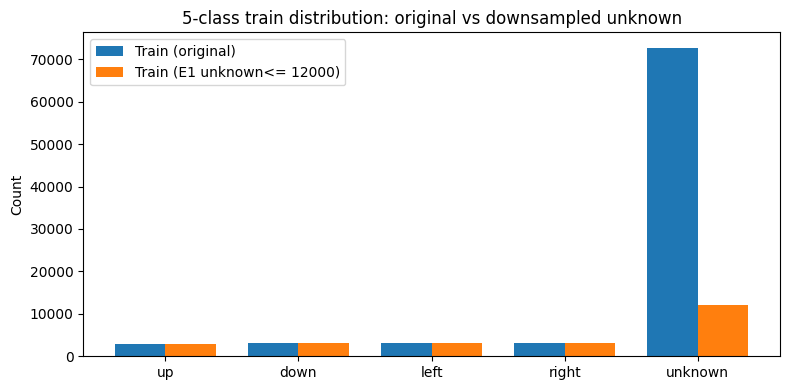

Saved figure: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/train_dist_5class_unknown_downsample_12000.png


In [6]:
import matplotlib.pyplot as plt

fig_dir = PROJECT_ROOT/"results/figures"
fig_dir.mkdir(parents=True, exist_ok=True)

counts_before = df5_train["target_label"].value_counts().reindex(FIVE_CLASS, fill_value=0)
counts_after  = df5_train_e1["target_label"].value_counts().reindex(FIVE_CLASS, fill_value=0)

x = np.arange(len(FIVE_CLASS))
width = 0.38

plt.figure(figsize=(8,4))
plt.bar(x - width/2, counts_before.values, width, label="Train (original)")
plt.bar(x + width/2, counts_after.values,  width, label=f"Train (E1 unknown<= {UNKNOWN_MAX})")
plt.xticks(x, FIVE_CLASS, rotation=0)
plt.ylabel("Count")
plt.title("5-class train distribution: original vs downsampled unknown")
plt.legend()
plt.tight_layout()

out_path = fig_dir/f"train_dist_5class_unknown_downsample_{UNKNOWN_MAX}.png"
plt.savefig(out_path, dpi=200)
plt.show()

print("Saved figure:", out_path)

#### Save E1 train-index (reproducibility)

In [7]:
e1_index_dir = PROJECT_ROOT/"data/processed/experiments"
e1_index_dir.mkdir(parents=True, exist_ok=True)

e1_index_path = e1_index_dir/f"index_5class_train_unknown_downsample_{UNKNOWN_MAX}_seed{SEED}.csv"
df5_train_e1.to_csv(e1_index_path, index=False)

print("Saved E1 train index:", e1_index_path)

Saved E1 train index: /content/drive/MyDrive/DAT255/voice-command-assistant/data/processed/experiments/index_5class_train_unknown_downsample_12000_seed42.csv


## 2. Training E1

In [8]:
import numpy as np
import librosa

SR = 16000
N_SAMPLES = 16000
N_MELS = 64
HOP_LENGTH = 160
N_FFT = 400

def pad_or_trim(x: np.ndarray, n_samples: int = N_SAMPLES) -> np.ndarray:
    x = x.astype(np.float32)
    if len(x) < n_samples:
        x = np.pad(x, (0, n_samples - len(x)), mode="constant")
    else:
        x = x[:n_samples]
    return x

def audio_to_mel_db(audio: np.ndarray, sr: int) -> np.ndarray:
    audio = audio.astype(np.float32)

    if sr != SR:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SR)

    audio = pad_or_trim(audio, N_SAMPLES)

    S = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmax=SR/2,
        power=2.0,
    )
    S_db = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    return S_db

print("audio_to_mel_db ready. Example shape:", audio_to_mel_db(np.zeros(16000, np.float32), 16000).shape)

audio_to_mel_db ready. Example shape: (64, 101)


#### Reuse Dataset + DataLoader

In [9]:
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import numpy as np
import torch

ds = load_dataset("google/speech_commands", "v0.02")

file_to_idx = {}
for split in ["train", "validation", "test"]:
    file_to_idx[split] = {ds[split][i]["file"]: i for i in range(len(ds[split]))}

print("Lookup built:",
      {k: len(v) for k,v in file_to_idx.items()})

class SpeechCommandsHFDataset(Dataset):
    def __init__(self, df, split_name):
        self.df = df.reset_index(drop=True)
        self.split = split_name

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        f = row["file"]

        hf_idx = file_to_idx[self.split][f]
        ex = ds[self.split][hf_idx]

        audio = ex["audio"]["array"].astype(np.float32)
        sr = ex["audio"]["sampling_rate"]

        S_db = audio_to_mel_db(audio, sr)
        X = torch.from_numpy(S_db).unsqueeze(0).float()

        y = label_to_5id[row["target_label"]]
        return X, y

train_ds_e1 = SpeechCommandsHFDataset(df5_train_e1, "train")
val_ds_5    = SpeechCommandsHFDataset(df5_val, "validation")
test_ds_5   = SpeechCommandsHFDataset(df5_test, "test")

train_loader_e1 = DataLoader(train_ds_e1, batch_size=32, shuffle=True, num_workers=0)
val_loader_5    = DataLoader(val_ds_5, batch_size=32, shuffle=False, num_workers=0)
test_loader_5   = DataLoader(test_ds_5, batch_size=32, shuffle=False, num_workers=0)

Xb, yb = next(iter(train_loader_e1))
print("Batch shapes:", Xb.shape, yb.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using the latest cached version of the dataset since google/speech_commands couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'v0.02' at /content/drive/MyDrive/DAT255/voice-command-assistant/data/cache/hf_datasets/google___speech_commands/v0.02/0.2.0/ba3d9a6cf49aa1313c51abe16b59203451482ccb9fee6d23c94fecabf3e206da (last modified on Wed Feb 25 14:03:30 2026).


Lookup built: {'train': 84848, 'validation': 9982, 'test': 4890}
Batch shapes: torch.Size([32, 1, 64, 101]) torch.Size([32])


#### Reuse CNN model

In [10]:
import torch.nn as nn

class SmallSpectrogramCNN(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Flatten(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

model_e1 = SmallSpectrogramCNN(n_classes=5).to(device)
print("Trainable params:", sum(p.numel() for p in model_e1.parameters() if p.requires_grad))

Trainable params: 23845


#### Training config

In [11]:
LR = 1e-3
EPOCHS = 10

optimizer = torch.optim.Adam(model_e1.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

#### Training loop (E1)

In [12]:
from sklearn.metrics import accuracy_score, f1_score

best_val_acc = 0

for epoch in range(EPOCHS):

    model_e1.train()

    train_losses = []
    train_preds = []
    train_targets = []

    for X, y in train_loader_e1:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model_e1(X)

        loss = criterion(logits, y)

        loss.backward()

        optimizer.step()

        train_losses.append(loss.item())

        preds = logits.argmax(dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(y.cpu().numpy())


    train_acc = accuracy_score(train_targets, train_preds)


    model_e1.eval()

    val_preds = []
    val_targets = []

    with torch.no_grad():

        for X, y in val_loader_5:

            X = X.to(device)
            y = y.to(device)

            logits = model_e1(X)

            preds = logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(y.cpu().numpy())


    val_acc = accuracy_score(val_targets, val_preds)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_acc {train_acc:.4f} | val_acc {val_acc:.4f}")

Epoch 1/10 | train_acc 0.5638 | val_acc 0.6396
Epoch 2/10 | train_acc 0.7298 | val_acc 0.8172
Epoch 3/10 | train_acc 0.7794 | val_acc 0.5197
Epoch 4/10 | train_acc 0.8014 | val_acc 0.3758
Epoch 5/10 | train_acc 0.8174 | val_acc 0.6246
Epoch 6/10 | train_acc 0.8350 | val_acc 0.8511
Epoch 7/10 | train_acc 0.8431 | val_acc 0.9094
Epoch 8/10 | train_acc 0.8525 | val_acc 0.5129
Epoch 9/10 | train_acc 0.8577 | val_acc 0.9065
Epoch 10/10 | train_acc 0.8635 | val_acc 0.7537


#### Evaluation

In [13]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate(model, loader):

    model.eval()

    preds = []
    targets = []

    with torch.no_grad():

        for X, y in loader:

            X = X.to(device)
            y = y.to(device)

            logits = model(X)

            p = logits.argmax(dim=1)

            preds.extend(p.cpu().numpy())
            targets.extend(y.cpu().numpy())

    acc = accuracy_score(targets, preds)
    macro_f1 = f1_score(targets, preds, average="macro")

    return acc, macro_f1, preds, targets


val_acc, val_f1, val_preds, val_targets = evaluate(model_e1, val_loader_5)
test_acc, test_f1, test_preds, test_targets = evaluate(model_e1, test_loader_5)

print("VAL  acc:", val_acc)
print("VAL  macro F1:", val_f1)

print("TEST acc:", test_acc)
print("TEST macro F1:", test_f1)

VAL  acc: 0.7536565818473252
VAL  macro F1: 0.5871054588765767
TEST acc: 0.6905930470347649
TEST macro F1: 0.6858327470447361


#### Confusion Matrix

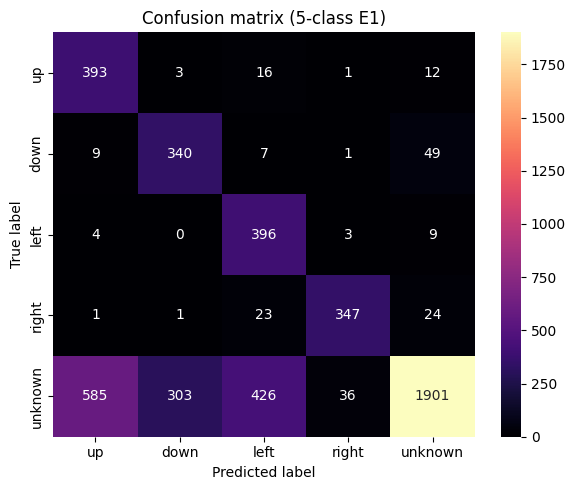

Saved figure: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/confusion_matrix_5class_E1.png


In [14]:
cm = confusion_matrix(test_targets, test_preds)

fig_dir = PROJECT_ROOT/"results/figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names_5,
    yticklabels=class_names_5,
    cmap="magma"
)

plt.title("Confusion matrix (5-class E1)")
plt.ylabel("True label")
plt.xlabel("Predicted label")

plt.tight_layout()

cm_path = fig_dir/"confusion_matrix_5class_E1.png"

plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved figure:", cm_path)

#### Save metrics

In [15]:
import pandas as pd
import time

run_name = f"cnn_5class_E1_downsample_{int(time.time())}"

metrics = pd.DataFrame([{
    "run_name": run_name,
    "val_acc": val_acc,
    "val_macro_f1": val_f1,
    "test_acc": test_acc,
    "test_macro_f1": test_f1
}])

metrics_dir = PROJECT_ROOT/"results/metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

metrics_path = metrics_dir/f"{run_name}_metrics.csv"

metrics.to_csv(metrics_path, index=False)

print("Saved:", metrics_path)
metrics

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/metrics/cnn_5class_E1_downsample_1772911102_metrics.csv


,run_name,val_acc,val_macro_f1,test_acc,test_macro_f1
0,cnn_5class_E1_downsample_1772911102,0.753657,0.587105,0.690593,0.685833


## 3. E2 - Audio augmentation

#### Augmentation functions

In [16]:
import numpy as np

def random_gain(x, rng, min_gain=0.7, max_gain=1.3):
    g = rng.uniform(min_gain, max_gain)
    return (x * g).astype(np.float32)

def random_time_shift(x, rng, max_shift=0.1):
    max_samp = int(max_shift * SR)
    if max_samp <= 0:
        return x
    shift = rng.randint(-max_samp, max_samp + 1)
    return np.roll(x, shift).astype(np.float32)

def add_gaussian_noise(x, rng, noise_std=0.005):
    n = rng.normal(0.0, noise_std, size=x.shape).astype(np.float32)
    return (x + n).astype(np.float32)

def augment_audio(x, seed, p_gain=0.7, p_shift=0.7, p_noise=0.7):
    rng = np.random.RandomState(seed)
    y = x.copy()

    if rng.rand() < p_gain:
        y = random_gain(y, rng)

    if rng.rand() < p_shift:
        y = random_time_shift(y, rng, max_shift=0.08)

    if rng.rand() < p_noise:
        y = add_gaussian_noise(y, rng, noise_std=0.004)

    y = np.clip(y, -1.0, 1.0).astype(np.float32)
    return y

print("Augmentation ready.")

Augmentation ready.


#### Train dataset with augmentation

In [17]:
import torch
from torch.utils.data import Dataset

class SpeechCommandsHFAugDataset(Dataset):
    def __init__(self, df, split_name, apply_augment=False, base_seed=123):
        self.df = df.reset_index(drop=True)
        self.split = split_name
        self.apply_augment = apply_augment
        self.base_seed = base_seed
        self.epoch = 0

    def set_epoch(self, epoch: int):
        self.epoch = int(epoch)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        f = row["file"]

        hf_idx = file_to_idx[self.split][f]
        ex = ds[self.split][hf_idx]

        audio = ex["audio"]["array"].astype(np.float32)
        sr = ex["audio"]["sampling_rate"]

        if sr != SR:
            audio = librosa.resample(audio, orig_sr=sr, target_sr=SR).astype(np.float32)
        audio = pad_or_trim(audio, N_SAMPLES)

        if self.apply_augment:
            seed = self.base_seed + 100000 * self.epoch + idx
            audio = augment_audio(audio, seed=seed)

        S_db = audio_to_mel_db(audio, SR)
        X = torch.from_numpy(S_db).unsqueeze(0).float()
        y = label_to_5id[row["target_label"]]
        return X, y


train_ds_e2 = SpeechCommandsHFAugDataset(df5_train_e1, "train", apply_augment=True, base_seed=SEED)
val_ds_e2   = SpeechCommandsHFAugDataset(df5_val, "validation", apply_augment=False, base_seed=SEED)
test_ds_e2  = SpeechCommandsHFAugDataset(df5_test, "test", apply_augment=False, base_seed=SEED)

train_loader_e2 = DataLoader(train_ds_e2, batch_size=32, shuffle=True, num_workers=0)
val_loader_e2   = DataLoader(val_ds_e2, batch_size=32, shuffle=False, num_workers=0)
test_loader_e2  = DataLoader(test_ds_e2, batch_size=32, shuffle=False, num_workers=0)

Xb, yb = next(iter(train_loader_e2))
print("E2 batch shapes:", Xb.shape, yb.shape)

E2 batch shapes: torch.Size([32, 1, 64, 101]) torch.Size([32])


#### Visual sanity check av augmentation

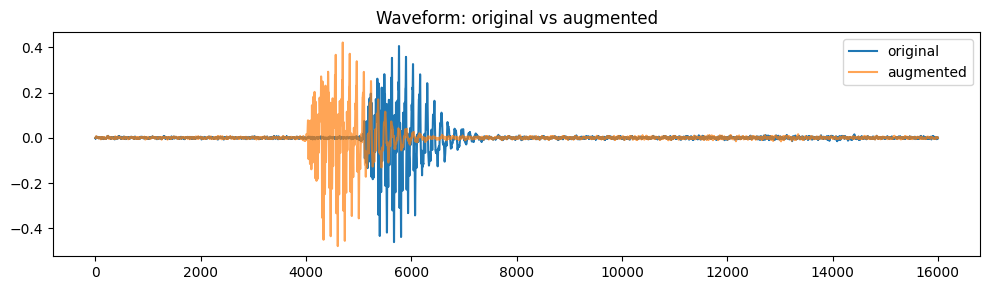

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/aug_waveform_original_vs_aug.png


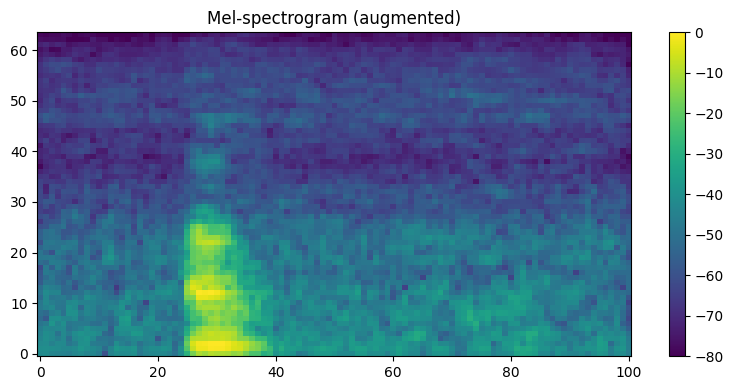

Saved: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/aug_melspectrogram_example.png


In [18]:
import matplotlib.pyplot as plt

row0 = df5_train_e1.iloc[0]
f0 = row0["file"]
hf0 = file_to_idx["train"][f0]
ex0 = ds["train"][hf0]
audio0 = ex0["audio"]["array"].astype(np.float32)
sr0 = ex0["audio"]["sampling_rate"]

if sr0 != SR:
    audio0 = librosa.resample(audio0, orig_sr=sr0, target_sr=SR).astype(np.float32)
audio0 = pad_or_trim(audio0, N_SAMPLES)

audio_aug = augment_audio(audio0, seed=SEED + 999)

mel0 = audio_to_mel_db(audio0, SR)
mel_aug = audio_to_mel_db(audio_aug, SR)

fig_dir = PROJECT_ROOT/"results/figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10,3))
plt.plot(audio0, label="original")
plt.plot(audio_aug, alpha=0.7, label="augmented")
plt.title("Waveform: original vs augmented")
plt.legend()
plt.tight_layout()
p1 = fig_dir/"aug_waveform_original_vs_aug.png"
plt.savefig(p1, dpi=200)
plt.show()
print("Saved:", p1)

plt.figure(figsize=(8,4))
plt.imshow(mel_aug, aspect="auto", origin="lower")
plt.title("Mel-spectrogram (augmented)")
plt.colorbar()
plt.tight_layout()
p2 = fig_dir/"aug_melspectrogram_example.png"
plt.savefig(p2, dpi=200)
plt.show()
print("Saved:", p2)

## 4. Experiment E2 — Training and evaluation

#### New model + optimizer + training loop with best checkpoint

In [20]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score

model_e2 = SmallSpectrogramCNN(n_classes=5).to(device)

LR = 1e-3
EPOCHS = 10

optimizer_e2 = torch.optim.Adam(model_e2.parameters(), lr=LR)
criterion_e2 = nn.CrossEntropyLoss()

best_val_acc_e2 = -1.0
best_state_e2 = None
best_epoch_e2 = -1

for epoch in range(EPOCHS):
    train_ds_e2.set_epoch(epoch)

    model_e2.train()
    train_preds, train_targets = [], []

    for X, y in train_loader_e2:
        X = X.to(device)
        y = y.to(device)

        optimizer_e2.zero_grad()
        logits = model_e2(X)
        loss = criterion_e2(logits, y)
        loss.backward()
        optimizer_e2.step()

        preds = logits.argmax(dim=1)
        train_preds.extend(preds.cpu().numpy())
        train_targets.extend(y.cpu().numpy())

    train_acc = accuracy_score(train_targets, train_preds)

    model_e2.eval()
    val_preds, val_targets = [], []

    with torch.no_grad():
        for X, y in val_loader_e2:
            X = X.to(device)
            y = y.to(device)

            logits = model_e2(X)
            preds = logits.argmax(dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(y.cpu().numpy())

    val_acc = accuracy_score(val_targets, val_preds)

    if val_acc > best_val_acc_e2:
        best_val_acc_e2 = val_acc
        best_epoch_e2 = epoch
        best_state_e2 = {k: v.cpu().clone() for k, v in model_e2.state_dict().items()}

    print(f"Epoch {epoch+1}/{EPOCHS} | train_acc {train_acc:.4f} | val_acc {val_acc:.4f}")

print("Best val_acc E2:", best_val_acc_e2, "at epoch", best_epoch_e2 + 1)

Epoch 1/10 | train_acc 0.5275 | val_acc 0.7512
Epoch 2/10 | train_acc 0.6837 | val_acc 0.7400
Epoch 3/10 | train_acc 0.7482 | val_acc 0.7568
Epoch 4/10 | train_acc 0.7764 | val_acc 0.7794
Epoch 5/10 | train_acc 0.7976 | val_acc 0.8424
Epoch 6/10 | train_acc 0.8120 | val_acc 0.8540
Epoch 7/10 | train_acc 0.8221 | val_acc 0.5508
Epoch 8/10 | train_acc 0.8300 | val_acc 0.6534
Epoch 9/10 | train_acc 0.8441 | val_acc 0.8180
Epoch 10/10 | train_acc 0.8437 | val_acc 0.6277
Best val_acc E2: 0.8540372670807453 at epoch 6


#### Load best E2 model + evaluate on val/test

In [22]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

model_e2.load_state_dict(best_state_e2)
model_e2.to(device)
model_e2.eval()

def evaluate_model(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)

            logits = model(X)
            p = logits.argmax(dim=1)

            preds.extend(p.cpu().numpy())
            targets.extend(y.cpu().numpy())

    acc = accuracy_score(targets, preds)
    macro_f1 = f1_score(targets, preds, average="macro")
    return acc, macro_f1, preds, targets

val_acc_e2, val_f1_e2, val_preds_e2, val_targets_e2 = evaluate_model(model_e2, val_loader_e2)
test_acc_e2, test_f1_e2, test_preds_e2, test_targets_e2 = evaluate_model(model_e2, test_loader_e2)

print("E2 VAL  acc:", val_acc_e2)
print("E2 VAL  macro F1:", val_f1_e2)
print("E2 TEST acc:", test_acc_e2)
print("E2 TEST macro F1:", test_f1_e2)

E2 VAL  acc: 0.8540372670807453
E2 VAL  macro F1: 0.6563901465143859
E2 TEST acc: 0.7838445807770961
E2 TEST macro F1: 0.706706365716285


#### Confusion matrix + save figure + save metrics

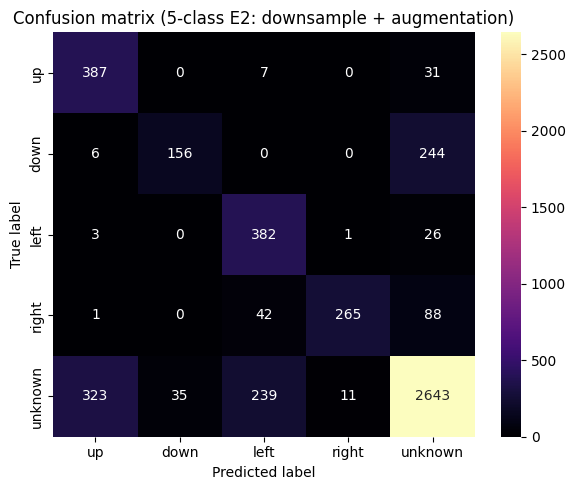

Saved figure: /content/drive/MyDrive/DAT255/voice-command-assistant/results/figures/confusion_matrix_5class_E2_downsample_aug.png
Saved metrics: /content/drive/MyDrive/DAT255/voice-command-assistant/results/metrics/cnn_5class_E2_downsample_aug_1772914070_metrics.csv


,run_name,best_val_acc,best_epoch,val_acc,val_macro_f1,test_acc,test_macro_f1
0,cnn_5class_E2_downsample_aug_1772914070,0.854037,6,0.854037,0.65639,0.783845,0.706706


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

cm_e2 = confusion_matrix(test_targets_e2, test_preds_e2)

fig_dir = PROJECT_ROOT/"results/figures"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_e2,
    annot=True,
    fmt="d",
    xticklabels=class_names_5,
    yticklabels=class_names_5,
    cmap="magma"
)
plt.title("Confusion matrix (5-class E2: downsample + augmentation)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()

cm_e2_path = fig_dir/"confusion_matrix_5class_E2_downsample_aug.png"
plt.savefig(cm_e2_path, dpi=200)
plt.show()
print("Saved figure:", cm_e2_path)

run_name_e2 = f"cnn_5class_E2_downsample_aug_{int(time.time())}"

metrics_e2 = pd.DataFrame([{
    "run_name": run_name_e2,
    "best_val_acc": float(best_val_acc_e2),
    "best_epoch": int(best_epoch_e2 + 1),
    "val_acc": float(val_acc_e2),
    "val_macro_f1": float(val_f1_e2),
    "test_acc": float(test_acc_e2),
    "test_macro_f1": float(test_f1_e2),
}])

metrics_dir = PROJECT_ROOT/"results/metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

metrics_e2_path = metrics_dir/f"{run_name_e2}_metrics.csv"
metrics_e2.to_csv(metrics_e2_path, index=False)

print("Saved metrics:", metrics_e2_path)
metrics_e2